# Diffusion Monte Carlo

Executable companion to chapter 15.

Chapter 14 ended with $E_{\rm VMC} = 3.000549 \pm 0.000049$ for two electrons in a
two-dimensional quantum dot, against Taut's exact $3$.  The residual
$5.5\times10^{-4}$ is eleven standard errors wide and entirely systematic: it is
what a two-parameter trial function cannot represent, and neither longer sampling
nor better optimisation removes it.

Diffusion Monte Carlo removes it by *projecting* rather than guessing.  Replacing
$t$ by $-i\tau$ turns the Schrodinger equation into

$$
-\frac{\partial\Phi}{\partial\tau} = (\hat H - E_T)\,\Phi ,
$$

whose formal solution filters every excited component away like
$e^{-(E_n-E_0)\tau}$.  In coordinate space this is a diffusion equation with a
source term, and a branching random walk simulates it directly.

The catch is that the source is the potential, and $1/r_{12}$ is unbounded.
Importance sampling fixes it: propagate $f = \Psi_T\Phi$ instead, which gives

$$
\frac{\partial f}{\partial\tau} = D\nabla^2 f - D\nabla\!\cdot\!(f\bm F)
  - (E_L - E_T) f ,
$$

with the same quantum force $\bm F = 2\nabla\Psi_T/\Psi_T$ and the same local
energy $E_L$ as in chapter 13 -- and the ground-state energy is the *mixed
estimator* $\langle E_L\rangle_f$, the same average of the same function, over a
different distribution.

Everything here uses `dmc.py`, which imports the trial function, local energy and
quantum force unchanged from `vmc.py`.

In [1]:
import sys
sys.path.insert(0, "../BookManybody/BookMaterial/Programs")

import math
import numpy as np
import matplotlib.pyplot as plt

import dmc
from vmc import TAUT_ENERGY, vmc_importance

plt.rcParams["figure.figsize"] = (7.0, 4.2)
print("exact (Taut)      ", TAUT_ENERGY)
print("VMC (chapter 14)  ", dmc.E_VMC)
print("guiding function  alpha =", dmc.ALPHA_OPT, " beta =", dmc.BETA_OPT)

exact (Taut)       3.0
VMC (chapter 14)   3.000549
guiding function  alpha = 1.0  beta = 0.4


## 1. The algorithm in its original form

No trial function, no drift, no accept/reject: walkers diffuse freely and are
branched with weight $\exp[-\Delta\tau(V - E_T)]$.  For the one-dimensional
harmonic oscillator, $V = x^2/2$, this works and the population growth alone
gives the energy.

In [2]:
naive = dmc.naive_dmc_harmonic(n_steps=3000)
print(f"E = {naive['energy']:.6f} +/- {naive['error']:.6f}   (exact {naive['exact']})")

E = 0.497322 +/- 0.002792   (exact 0.5)


That works because $x^2/2$ is smooth and bounded below.  Put $1/r_{12}$ in the
exponent instead and the weights diverge as two walkers approach: one lucky
configuration acquires an enormous weight, spawns an enormous number of copies,
and the whole population descends from it.  The variance is unbounded and no
amount of computer time helps.

Importance sampling replaces $V$ by $E_L$, which the cusp condition keeps finite.
That is the whole argument, and it is why the algorithm of this cell is never the
algorithm that is used.

## 2. The quantum dot

One run at $\Delta\tau = 0.05$ with 500 walkers, started from a short variational
Monte Carlo run at the same parameters.  Two independent estimators come out: the
mixed estimator $\langle E_L\rangle_f$, and the growth estimator, which is the
average of the trial energy $E_T$ needed to hold the population steady.

In [3]:
result = dmc.dmc(n_walkers=500, n_steps=4000, time_step=0.05,
                 rng=np.random.default_rng(2024))
print(f"acceptance        {result['acceptance']:.1%}")
print(f"mean population   {result['mean_population']:.0f}")
print(f"var(E_L)          {result['variance']:.5f}")
print(f"correlation time  {result['tau']:.2f}")
print()
print(f"mixed estimator   E = {result['energy']:.6f} +/- {result['error']:.6f}")
print(f"growth estimator  E = {result['growth']:.6f} +/- {result['growth_error']:.6f}")
print(f"exact                 {TAUT_ENERGY:.6f}")

acceptance        99.5%
mean population   500
var(E_L)          0.00223
correlation time  7.18

mixed estimator   E = 3.000216 +/- 0.000115
growth estimator  E = 2.999778 +/- 0.000619
exact                 3.000000


The two agree, as they must.  The mixed estimator has by far the smaller error --
it measures the eigenvalue directly, while the growth estimator infers it from a
population that is itself noisy -- and it is the one that gets quoted.

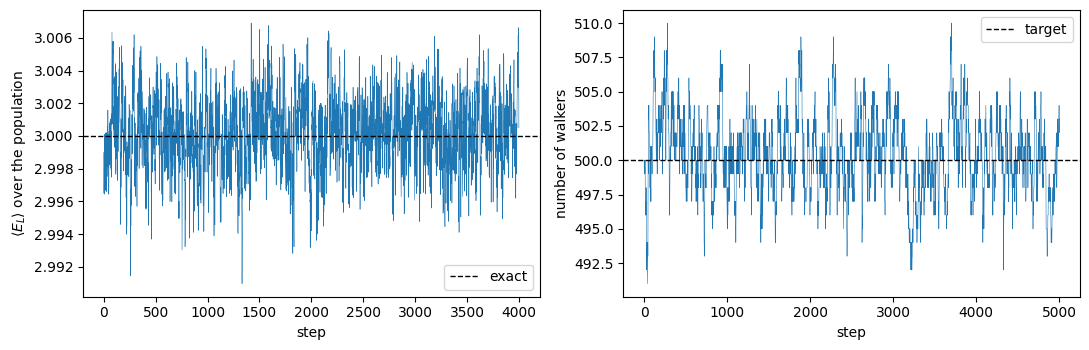

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 3.6))
left.plot(result["series"], lw=0.4)
left.axhline(TAUT_ENERGY, color="k", ls="--", lw=1, label="exact")
left.set_xlabel("step")
left.set_ylabel(r"$\langle E_L\rangle$ over the population")
left.legend()
right.plot(result["population"], lw=0.4)
right.axhline(500, color="k", ls="--", lw=1, label="target")
right.set_xlabel("step")
right.set_ylabel("number of walkers")
right.legend()
fig.tight_layout()
plt.show()

The population wanders around its target but is held there by the feedback in

$$
E_T = \bar E - \frac{\kappa}{\Delta\tau}
      \ln\frac{N_{\rm walkers}}{N_{\rm target}} ,
$$

with a deliberately weak $\kappa = 0.05$: $E_T$ sits in the branching exponent, so
a violent controller injects its own fluctuations into the simulation.

## 3. The time step is the systematic error

The short-time Green's function is exact only as $\Delta\tau\to0$, so a
calculation that quotes one time step has not finished.  Run at several and
extrapolate.

`effective_time_step` replaces $\Delta\tau$ in the branching factor by

$$
\Delta\tau_{\rm eff} = \Delta\tau
  \frac{\sum_{\rm accepted}(\Delta\bm R)^2}{\sum_{\rm attempted}(\Delta\bm R)^2},
$$

which corrects the branching for the moves the accept/reject step threw away.

In [5]:
time_steps = [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
scans = {}
for label, use_eff in (("plain dt", False), ("dt_eff", True)):
    energies, errors = [], []
    print(label)
    print(f"{'dt':>8s} {'energy':>12s} {'error':>10s} {'accept':>8s} "
          f"{'dteff/dt':>9s} {'tau':>6s}")
    for dt in time_steps:
        out = dmc.dmc(n_walkers=500, n_steps=4000, time_step=dt,
                      effective_time_step=use_eff,
                      rng=np.random.default_rng(2024))
        energies.append(out["energy"])
        errors.append(out["error"])
        print(f"{dt:8.3f} {out['energy']:12.6f} {out['error']:10.6f} "
              f"{out['acceptance']:8.1%} "
              f"{out['effective_time_step']/dt:9.3f} {out['tau']:6.1f}")
    fit = dmc.extrapolate(time_steps, energies, errors)
    scans[label] = (np.array(energies), np.array(errors), fit)
    print(f"  extrapolated {fit['intercept']:.6f} +/- {fit['intercept_error']:.6f}"
          f"   slope {fit['coefficients'][1]:+.5f}")
    print()

plain dt
      dt       energy      error   accept  dteff/dt    tau


   0.500     2.999835   0.000050    87.2%     1.000    1.2


   0.300     2.999889   0.000057    93.6%     1.000    1.7


   0.200     2.999959   0.000068    96.4%     1.000    2.3


   0.100     3.000098   0.000089    98.6%     1.000    4.2


...

   0.300     3.000040   0.000058    93.6%     0.899    1.7


   0.200     2.999946   0.000065    96.4%     0.942    2.3


   0.100     3.000155   0.000096    98.7%     0.978    5.2


   0.050     3.000216   0.000115    99.5%     0.991    7.2


   0.020     2.999736   0.000167    99.9%     0.998   18.3
  extrapolated 3.000090 +/- 0.000094   slope -0.00031



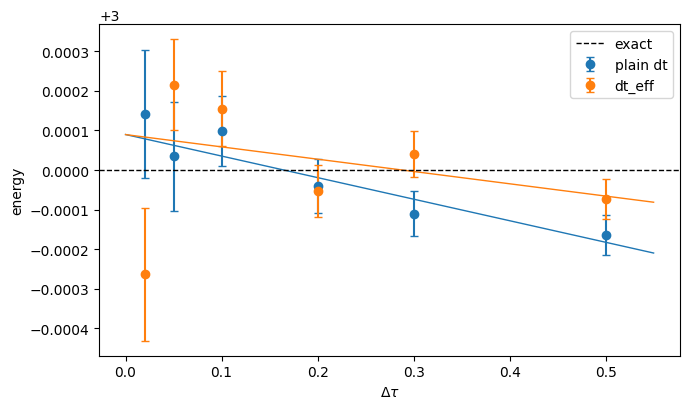

In [6]:
grid = np.linspace(0.0, 0.55, 100)
for label, (energies, errors, fit) in scans.items():
    line = plt.errorbar(time_steps, energies, yerr=errors, fmt="o", capsize=3,
                        label=label)
    plt.plot(grid, fit["coefficients"][0] + fit["coefficients"][1] * grid,
             lw=1, color=line[0].get_color())
plt.axhline(TAUT_ENERGY, color="k", ls="--", lw=1, label="exact")
plt.xlabel(r"$\Delta\tau$")
plt.ylabel("energy")
plt.legend()
plt.tight_layout()
plt.show()

Three things to read off.

The acceptance rate stays above 87% even at $\Delta\tau = 0.5$ -- that is what the
drift buys, and it is unchanged from chapter 13.  The $\Delta\tau_{\rm eff}$
correction is substantial at the largest time step and negligible below 0.05,
exactly as it should be.

The correlation time in *steps* grows as the time step shrinks.  What decorrelates
a walker is imaginary time: 4000 steps at $\Delta\tau = 0.02$ cover eighty units
of $\tau$ where the same number at $\Delta\tau = 0.5$ cover two thousand.  A small
time step is not free.

And the bias itself is minute, a few parts in $10^4$ across a factor of
twenty-five in $\Delta\tau$.  That is a statement about the guiding function, not
about the method: the time-step error comes from the commutators the Trotter
factorisation drops, and those vanish when $\Psi_T$ is an eigenfunction.  At
$\alpha = 1$ the local energy of this dot is very nearly constant, so there is
almost nothing for the factorisation to get wrong.

## 4. A deliberately bad guiding function

$\alpha = 0.80$, $\beta = 0.10$ is a long way from the variational minimum.  In
chapter 13 that would simply be a worse answer.  Here it is not.

In [2]:
poor_vmc = vmc_importance(0.80, 0.10, n_cycles=60000, time_step=0.5,
                          rng=np.random.default_rng(7))
print(f"VMC with the same trial function: {poor_vmc['energy']:.6f} "
      f"+/- {poor_vmc['error']:.6f}   (variance {poor_vmc['variance']:.4f})")
print()

poor_steps = [0.1, 0.05, 0.02, 0.01]
energies, errors = [], []
print(f"{'dt':>8s} {'energy':>12s} {'error':>10s} {'tau':>6s}")
for dt in poor_steps:
    out = dmc.dmc(alpha=0.80, beta=0.10, n_walkers=2000, n_steps=3000,
                  time_step=dt, rng=np.random.default_rng(2024))
    energies.append(out["energy"])
    errors.append(out["error"])
    print(f"{dt:8.3f} {out['energy']:12.6f} {out['error']:10.6f} {out['tau']:6.1f}")
poor_fit = dmc.extrapolate(poor_steps, energies, errors)
print(f"  extrapolated {poor_fit['intercept']:.6f} "
      f"+/- {poor_fit['intercept_error']:.6f}   "
      f"slope {poor_fit['coefficients'][1]:+.5f}")

VMC with the same trial function: 3.363877 +/- 0.005019   (variance 0.6227)

      dt       energy      error    tau


   0.100     3.025847   0.000966    8.0


   0.050     3.014878   0.001555   20.5


   0.020     3.002270   0.002293   52.8


   0.010     3.005206   0.002222   50.6
  extrapolated 3.001071 +/- 0.002338   slope +0.24931


Variationally this trial function is a disaster -- 3.36 against an exact 3, worse
than Hartree-Fock in a 42-orbital basis.  Projected, it gives the right answer.

The price shows up everywhere else: an error bar some twenty-five times larger
despite four times the walkers, correlation times three times longer, and a
time-step slope a few hundred times steeper, so that $\Delta\tau = 0.5$ is no
longer usable at all.  A poor guiding function costs computer time and demands a
smaller time step.  It does not cost accuracy.

## 5. Is it a population-control bias?

A systematic error that does not move with $\Delta\tau$ often turns out to move
with the number of walkers instead, because the feedback that stabilises the
population correlates the walkers with each other.  Worth checking rather than
assuming.

In [3]:
print(f"{'walkers':>8s} {'good guide':>24s} {'poor guide':>24s}")
for n in (250, 500, 1000, 2000):
    good = dmc.dmc(n_walkers=n, n_steps=3000, time_step=0.1,
                   rng=np.random.default_rng(2024))
    bad = dmc.dmc(alpha=0.80, beta=0.10, n_walkers=n, n_steps=3000,
                  time_step=0.1, rng=np.random.default_rng(2024))
    print(f"{n:8d} {good['energy']:16.6f} +/- {good['error']:.6f} "
          f"{bad['energy']:14.6f} +/- {bad['error']:.6f}")

 walkers               good guide               poor guide


     250         2.999874 +/- 0.000131       3.024045 +/- 0.003611


     500         3.000158 +/- 0.000099       3.021299 +/- 0.002181


    1000         2.999966 +/- 0.000062       3.022742 +/- 0.001509


    2000         2.999934 +/- 0.000044       3.025847 +/- 0.000966


Neither central value drifts over a factor of eight in the population, while the
error bars fall by the expected $\sqrt 8 \approx 2.8$.  The population-control
bias is below the statistical resolution here, so the residual in the poor-guide
column is time-step error -- which section 3 removes by extrapolating.

## 6. Where this leaves the quantum dot

| method | energy | error |
|---|---|---|
| Hartree-Fock, 42 orbitals | 3.161921 | $1.6\times10^{-1}$ |
| MP2, 42 orbitals | 3.027038 | $2.7\times10^{-2}$ |
| CCSD, 42 orbitals | 3.013626 | $1.4\times10^{-2}$ |
| VMC, optimised (chapter 14) | 3.000549(49) | $5.5\times10^{-4}$ |
| DMC, extrapolated | 3.000090(64) | $9.0\times10^{-5}$ |
| exact (Taut) | 3.000000 | --- |

The basis-set methods are limited by the basis: no finite sum of oscillator
products reproduces the cusp at $r_{12} = 0$.  Variational Monte Carlo removes the
basis but is limited by the ansatz.  Diffusion Monte Carlo removes the ansatz too,
and what is left is statistics.

## What is not here

The two-electron singlet has a symmetric spatial wave function, so $\Psi_T$ is
strictly positive and there are no nodes.  For fermions in general there are, the
projector converges on the nodeless *bosonic* state instead, and the fermionic
signal decays like $e^{-(E_0^{\rm F}-E_0^{\rm B})\tau}$ -- the sign problem.  The
fixed-node approximation constrains $\Phi$ to vanish where $\Psi_T$ does, which
restores a positive $f$ and gives a variational upper bound, exact only if the
nodes are.  It is the one error in this chapter that cannot be removed by
spending more computer time, and improving it means improving the *nodes* of the
trial function rather than its amplitude.

Which is where flexible parametrisations -- neural-network wave functions,
optimised with the gradient and the stochastic reconfiguration of chapter 14 --
come in.